# K-Nearest Neighbours

K-Nearest Neighbors is a supervised machine learning algorithm used for classification and regression. It works by finding the K closest data points to a new data point and assigning the majority label among those neighbors.


- Distance based algorithm
- Works well with small datasets


KNN uses Euclidean or Manhattan distance.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
uploaded = files.upload()

Saving file.csv to file (5).csv


## Euclidean vs Manhattan Distance

Euclidean -> Straight Line distance between 2 points **(default)**

Manhattan -> Distance along grid line path

Euclidean is sensitive to large differences, which Manhattan is robust to outliers, and works well in **high-dimension datasets**.

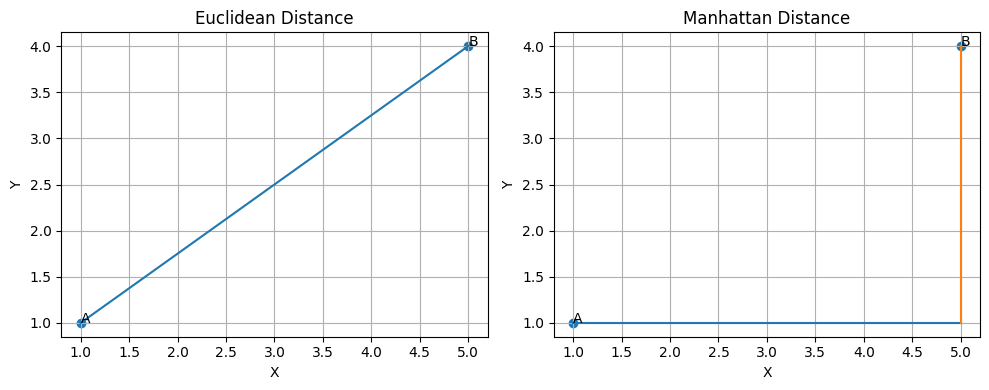

In [ ]:
x1, y1 = 1, 1;x2, y2 = 5, 4;fig, axes = plt.subplots(1, 2, figsize=(10,4));axes[0].scatter([x1, x2], [y1, y2]);axes[0].plot([x1, x2], [y1, y2]);axes[0].set_title("Euclidean Distance");axes[0].set_xlabel("X");axes[0].set_ylabel("Y");axes[0].text(x1, y1, "A");axes[0].text(x2, y2, "B");axes[0].grid(True)
axes[1].scatter([x1, x2], [y1, y2]);axes[1].plot([x1, x2], [y1, y1]);axes[1].plot([x2, x2], [y1, y2]);
axes[1].set_title("Manhattan Distance");axes[1].set_xlabel("X");axes[1].set_ylabel("Y");axes[1].text(x1, y1, "A");axes[1].text(x2, y2, "B");axes[1].grid(True);plt.tight_layout();plt.show();

## Dataset

Age → customer age

EstimatedSalary → yearly salary

Purchased →

0 = No purchase

1 = Purchased

Goal:
**Predict whether a user will purchase a product.**

In [ ]:
df = pd.read_csv("file.csv")
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


When to use:

- Dataset is small
- Pattern is non-linear
- Simple baseline model needed
- No assumptions about data distribution

Avoid when:
- Dataset is very large
- Many features (high dimensionality)

## Visualization



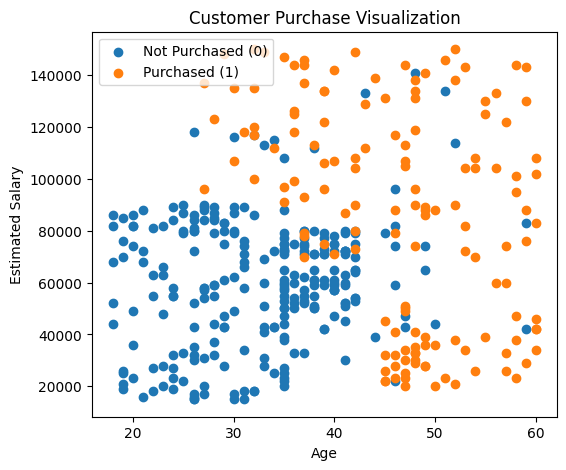

In [ ]:
purchased_0 = df[df["Purchased"] == 0]
purchased_1 = df[df["Purchased"] == 1]
plt.figure(figsize=(6,5))
plt.scatter(purchased_0["Age"], purchased_0["EstimatedSalary"], label="Not Purchased (0)")
plt.scatter(purchased_1["Age"], purchased_1["EstimatedSalary"], label="Purchased (1)")
plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.title("Customer Purchase Visualization")
plt.legend()
plt.show()

## Train-Test Splitting

In [ ]:
from sklearn.model_selection import train_test_split

X = df[["Age", "EstimatedSalary"]]
y = df["Purchased"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

## Feature Scaling

Since KNN relies on distance, we must use feature scaling.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Hyperparameter Tuning

**K** = number of nearest neighbors used to make the prediction.

K = 3 → look at the 3 closest points

K = 5 → look at the 5 closest points

The algorithm then chooses the majority class among those neighbors.

Let's try different values of K to determine what fits the best

In [ ]:
from sklearn.metrics import accuracy_score

for k in range(1,10):
    knnmodel = KNeighborsClassifier(n_neighbors=k)
    knnmodel.fit(X_train, y_train)
    pred = knnmodel.predict(X_test)
    print(k, accuracy_score(y_test, pred))

1 0.825
2 0.7875
3 0.7875
4 0.825
5 0.8375
6 0.875
7 0.875
8 0.8625
9 0.8625


K =

1 0.825 -> Overfitting

2 0.7875 -> Low Accuracy

3 0.7875 -> Low Accuracy

4 0.825 -> Low Accuracy

5 0.8375 -> Medium Accuracy

6 0.875 -> Best Accuracy

7 0.875 -> Best Accuracy

## Training

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knnmodel = KNeighborsClassifier(n_neighbors=7)

In [ ]:
knnmodel.fit(X_train, y_train)

y_pred = knnmodel.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

In [ ]:
accuracy

0.875

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[54  4]
 [ 6 16]]


|Meaning|Predicted Negative| Predicted Positive|
|---|---|---|
|Actual Negative| 54| 4|
|Actual Positive| 6| 16|

# Logistic Regression

Logistic Regression is a supervised machine learning algorithm used for classification problems, especially binary classification.

It predicts the probability that an input belongs to a particular class.

- Spam detection

- Disease prediction

- Customer purchase prediction

Unlike Linear Regression, logistic regression outputs probabilities between 0 and 1.

**To achieve this, logistic regression uses the Sigmoid Function (also called the logistic function).**

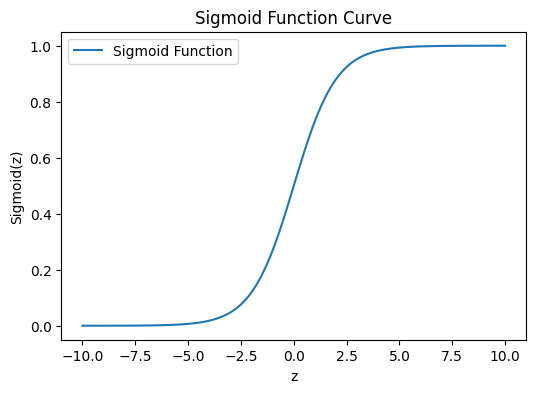

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
x = np.linspace(-10, 10, 100)
y = sigmoid(x)
plt.figure(figsize=(6,4))
plt.plot(x, y, label="Sigmoid Function")
plt.xlabel("z")
plt.ylabel("Sigmoid(z)")
plt.title("Sigmoid Function Curve")
plt.legend()
plt.show()

Sigmoid Function

The sigmoid function transforms any real number into a value between 0 and 1, making it ideal for probability estimation.

Mathematical form:

<h2><i>
σ(z)=
1+e<sup>-z</sup>
</h2>	​</i>

where Sigmoid Function

The sigmoid function transforms any real number into a value between 0 and 1, making it ideal for probability estimation.

Mathematical form:

𝜎(𝑧) = 1 + 𝑒<sup>−𝑧</sup>


Where:

**𝑧 = 𝑤1𝑥1 + 𝑤2𝑥2 + ... + 𝑏**

𝑤 are model weights

𝑥 are input features

𝑏 is the bias term

𝑤 are model weights

𝑥 are input features

𝑏 is the bias term

How It Works in Logistic Regression

- The model first computes a linear combination of input features
his value is passed through the sigmoid function.

- The output becomes a probability between 0 and 1.

**Decision Rule**

The predicted probability is converted into a class label using a threshold:

If P ≥ 0.5 → Class 1

If P < 0.5 → Class 0

Thus, logistic regression converts linear outputs into probabilistic predictions for classificatio

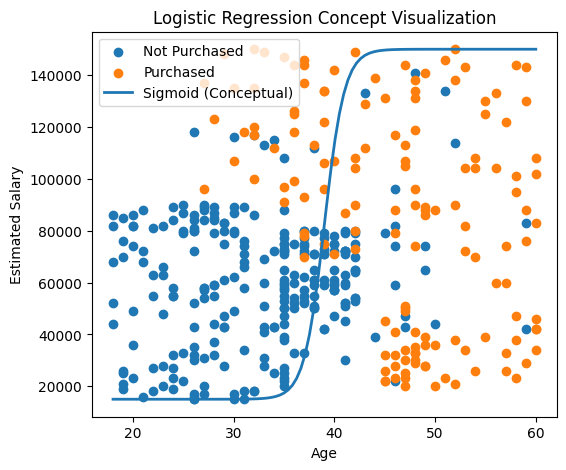

In [ ]:
purchased_0 = df[df["Purchased"] == 0];purchased_1 = df[df["Purchased"] == 1];plt.figure(figsize=(6,5));plt.scatter(purchased_0["Age"], purchased_0["EstimatedSalary"], label="Not Purchased");plt.scatter(purchased_1["Age"], purchased_1["EstimatedSalary"], label="Purchased");
x = np.linspace(df["Age"].min(), df["Age"].max(), 100)
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
y = sigmoid(x - x.mean());y = y * (df["EstimatedSalary"].max() - df["EstimatedSalary"].min()) + df["EstimatedSalary"].min();plt.plot(x, y, label="Sigmoid (Conceptual)", linewidth=2);plt.xlabel("Age");plt.ylabel("Estimated Salary");plt.title("Logistic Regression Concept Visualization");plt.legend();plt.show();

## Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
df = pd.read_csv("file.csv")
scaler = StandardScaler()
X = df[["Age", "EstimatedSalary"]]
y = df["Purchased"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

lrmodel = LogisticRegression()
lrmodel.fit(X_train, y_train)

LogisticRegression()

In [ ]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.875


In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[54  4]
 [ 6 16]]


|Meaning|Predicted Negative| Predicted Positive|
|---|---|---|
|Actual Negative| 54| 4|
|Actual Positive| 6| 16|

## Data Generator

In [ ]:
def generate_new_data(n=10):
    ages = np.random.randint(18, 50, n)
    salaries = np.random.randint(20000, 150000, n)
    new_df = pd.DataFrame({
        "Age": ages,
        "EstimatedSalary": salaries
    })
    return new_df

In [ ]:
new_df = generate_new_data(10)
print(new_df)

   Age  EstimatedSalary
0   22            70050
1   49            95796
2   45           119000
3   34            66466
4   32            56909
5   36           145734
6   20            97075
7   23           149567
8   44           102619
9   39            61104


In [ ]:
lrmodel.predict(new_df)

array([0, 1, 1, 0, 0, 1, 0, 0, 1, 0])

In [ ]:
knnmodel.predict(new_df)

array([0, 1, 1, 0, 0, 1, 1, 1, 1, 0])

In [ ]:
x,y = lrmodel.predict(new_df),knnmodel.predict(new_df)
new_df["Logistic Regression"] = x
new_df["KNN"] = y
new_df

,Age,EstimatedSalary,Logistic Regression,KNN
0,22,70050,0,0
1,49,95796,1,1
2,45,119000,1,1
3,34,66466,0,0
4,32,56909,0,0
5,36,145734,1,1
6,20,97075,0,1
7,23,149567,0,1
8,44,102619,1,1
9,39,61104,0,0




> Mayank Sharma For today please study all those models you used , also try to solve some questions for them. so that you get better understanding of the models .

What kind of Questions ?

KNN

- How does KNN classify a new point?

- Why is feature scaling important?

- What happens when K is very small or very large?

- What distance metric is used?

Logistic Regression

- Why does it use the Sigmoid Function?

- How does it convert linear output to probability?

- What is the decision boundary?

</div>


# Decision Trees

It works by splitting the dataset into smaller subsets based on feature values, forming a tree-like structure.

Each internal node represents a decision based on a feature, and each leaf node represents a final prediction.


```
Age < 30 ?

   ├── Yes → Not Purchased

   └── No  → Salary > 10000 ?
        
        ├── Yes → Not Purchased
        
        └── No  → Salary > 10000 ?

The Decision Tree splits data based on rules that maximize class separation.

It chooses splits using criteria such as:

- Gini Impurity

- Information Gain

- Entropy